In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy
import pickle
import random
import seaborn as sns
import matplotlib.ticker as ticker


from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                mean_abs_cntrl = np.mean( [max_cntrl_[v], np.abs(min_cntrl_[v])] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_abs_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

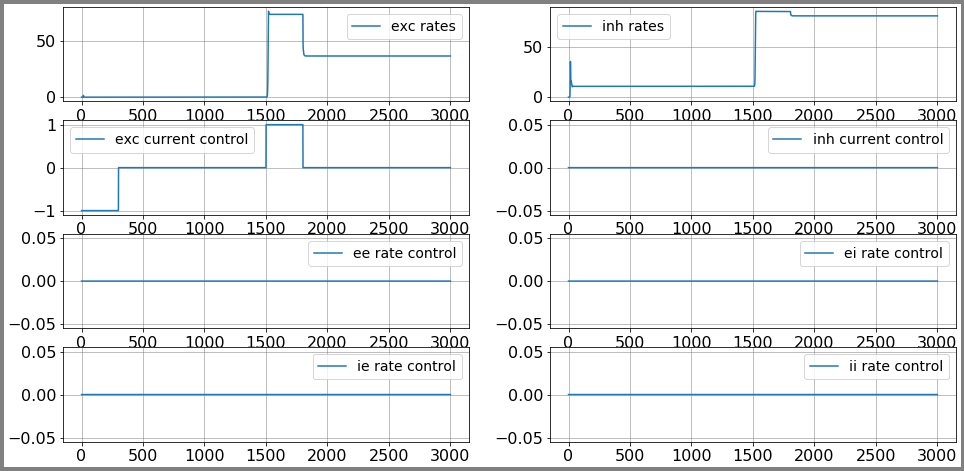

[[3.6659e+01 8.0465e+01]
 [1.0118e-05 1.0712e+01]]


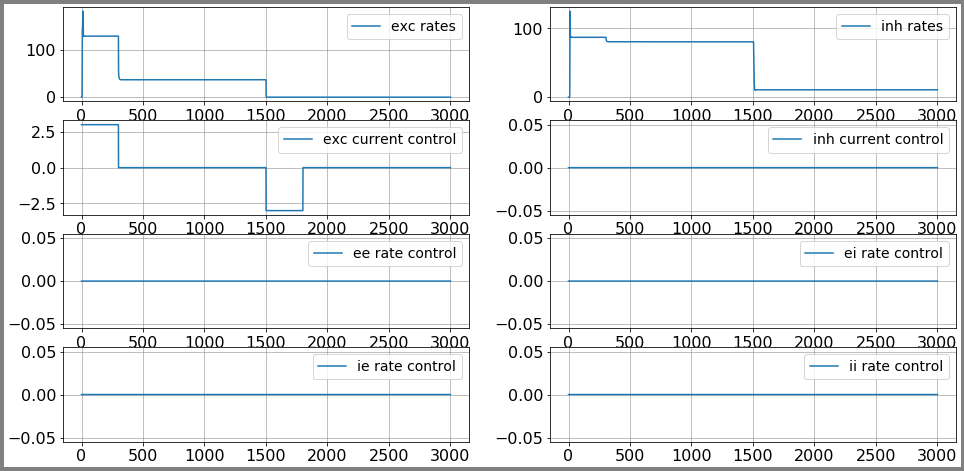

In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 0.45 * 5.
aln.params.ext_inh_current = 0.4 * 5.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]


In [4]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

bestControla = [ [], [], []]
bestStatea = [ [], [], []]
costa = [ [], [], []]
runtimea = [ [], [], []]
grada = [ [], [], []]
phia = [ [], [], []]
costnodea = [ [], [], []]
weightsa = [ [], [], [], [], [], [], [], [] ]

bestControlb = [ [], [], [], [], [], [], [], [] ]
bestStateb = [ [], [], [], [], [], [], [], [] ]
costb = [ [], [], [], [], [], [], [], [] ]
runtimeb = [ [], [], [], [], [], [], [], [] ]
gradb = [ [], [], [], [], [], [], [], [] ]
phib = [ [], [], [], [], [], [], [], [] ]
costnodeb = [ [], [], [], [], [], [], [], [] ]
weightsb = [ [], [], [], [], [], [], [], [] ]

bestControlc = [ [], [], [], [], [], [], [], [] ]
bestStatec = [ [], [], [], [], [], [], [], [] ]
costc = [ [], [], [], [], [], [], [], [] ]
runtimec = [ [], [], [], [], [], [], [], [] ]
gradc = [ [], [], [], [], [], [], [], [] ]
phic = [ [], [], [], [], [], [], [], [] ]
costnodec = [ [], [], [], [], [], [], [], [] ]
weightsc = [ [], [], [], [], [], [], [], [] ]

bestControld = [ [], [], [], [], [], [], [], [] ]
bestStated = [ [], [], [], [], [], [], [], [] ]
costd = [ [], [], [], [], [], [], [], [] ]
runtimed = [ [], [], [], [], [], [], [], [] ]
gradd = [ [], [], [], [], [], [], [], [] ]
phid = [ [], [], [], [], [], [], [], [] ]
costnoded = [ [], [], [], [], [], [], [], [] ]
weightsd = [ [], [], [], [], [], [], [], [] ]

bestControle = [ [], [], [], [], [], [], [], [] ]
bestStatee = [ [], [], [], [], [], [], [], [] ]
coste = [ [], [], [], [], [], [], [], [] ]
runtimee = [ [], [], [], [], [], [], [], [] ]
grade = [ [], [], [], [], [], [], [], [] ]
phie = [ [], [], [], [], [], [], [], [] ]
costnodee = [ [], [], [], [], [], [], [], [] ]
weightse = [ [], [], [], [], [], [], [], [] ]

In [5]:
cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])
initVars = low_state_vars

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

sheet = "state_switching"
max_it = 2000

### Cases

Numer | Input | Input label | Result
---------|--------------|-----------|-----------
1 | E current | 0 | 0
2 | I current | 1 | 0
3 | E + I current | 0,1 | 0
4 | EE rate | 2 | 0
5 | EI rate | 3 | 0
6 | IE rate | 4 | 0
7 | II rate | 5 | 0
8 | EE + EI + IE + II rate | 2,3,4,5 | 0

- a) precision cost only
- b) precision + energy just below maximum
- c) precision + energy just beyond zero control for one/ both inputs
- d) precision + sparsity just below maximum
- e) precision + sparsity just beyond zero control for one/ both inputs

## 3

In [21]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 10

weightsa = [ [], [], [], [], [], [], [], [] ]
weightsa[c_] = cost.getParams()

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_], costnodea[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,prec_variables_ = prec_vars, transition_time_ = trans_time)

#plotFunc.plot_control(aln, [bestControla[c_]], [costnodea[c_]], [weightsa[c_]], dur, dur_pre, dur_post, initVars, target,
 #                     path, filename_ = case, transition_time_ = trans_time, labels_ = ["a"])
#plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params:  1.0 0.0 0.0
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13438.094126405349
Gradient descend method:  None
RUN  1 , total integrated cost =  3331.0011619072775
RUN  2 , total integrated cost =  390.01338726335985
RUN  3 , total integrated cost =  235.13799445485313
RUN  4 , total integrated cost =  155.10014883760005
RUN  5 , total integrated cost =  101.87513721266812
RUN  6 , total integrated cost =  72.82543549248304
RUN  7 , total integrated cost =  58.51087457148187
RUN  8 , total integrated cost =  46.59960233095046
RUN  9 , total integrated cost =  37.506793831497916
RUN  10 , total integrated cost =  29.93428283649365


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  29.93428283649365
Improved over  10  iterations in  0.444347300000004  seconds by  99.77724309299431  percent.
Problem in initial value trasfer:  Vmean_exc -56.01503302708645 -56.01006443876498


set cost params:  1.0 19000.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13071.174173079828
Gradient descend method:  None
RUN  1 , total integrated cost =  13070.931581613171
RUN  2 , total integrated cost =  13070.922455878326
RUN  3 , total integrated cost =  13070.920027000953
RUN  4 , total integrated cost =  13070.919999876092
RUN  5 , total integrated cost =  13070.918085830392
RUN  6 , total integrated cost =  13070.917108019774
RUN  7 , total integrated cost =  13070.917103081858
RUN  8 , total integrated cost =  13070.917100112885
RUN  9 , total integrated cost =  13070.913506941246
RUN  10 , total integrated cost =  13070.913486270205
RUN  11 , total integrated cost =  13070.91348610912
RUN  12 , total integrated cost =  13070.913486107678
RUN  13 , total integrated cost =  13070.913486107658


ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  13070.913486107656
State only changes marginally.
RUN  15 , total integrated cost =  13070.913486107656
Control only changes marginally.
RUN  15 , total integrated cost =  13070.913486107656
Improved over  15  iterations in  1.049527600000033  seconds by  0.001994365377726126  percent.
Problem in initial value trasfer:  Vmean_exc -55.95837927085149 -55.958406327671895
max, min in exc array =  0.13464896806046908 0.0
max, min in inh array =  6.27961597793542e-11 -0.27570651234883237


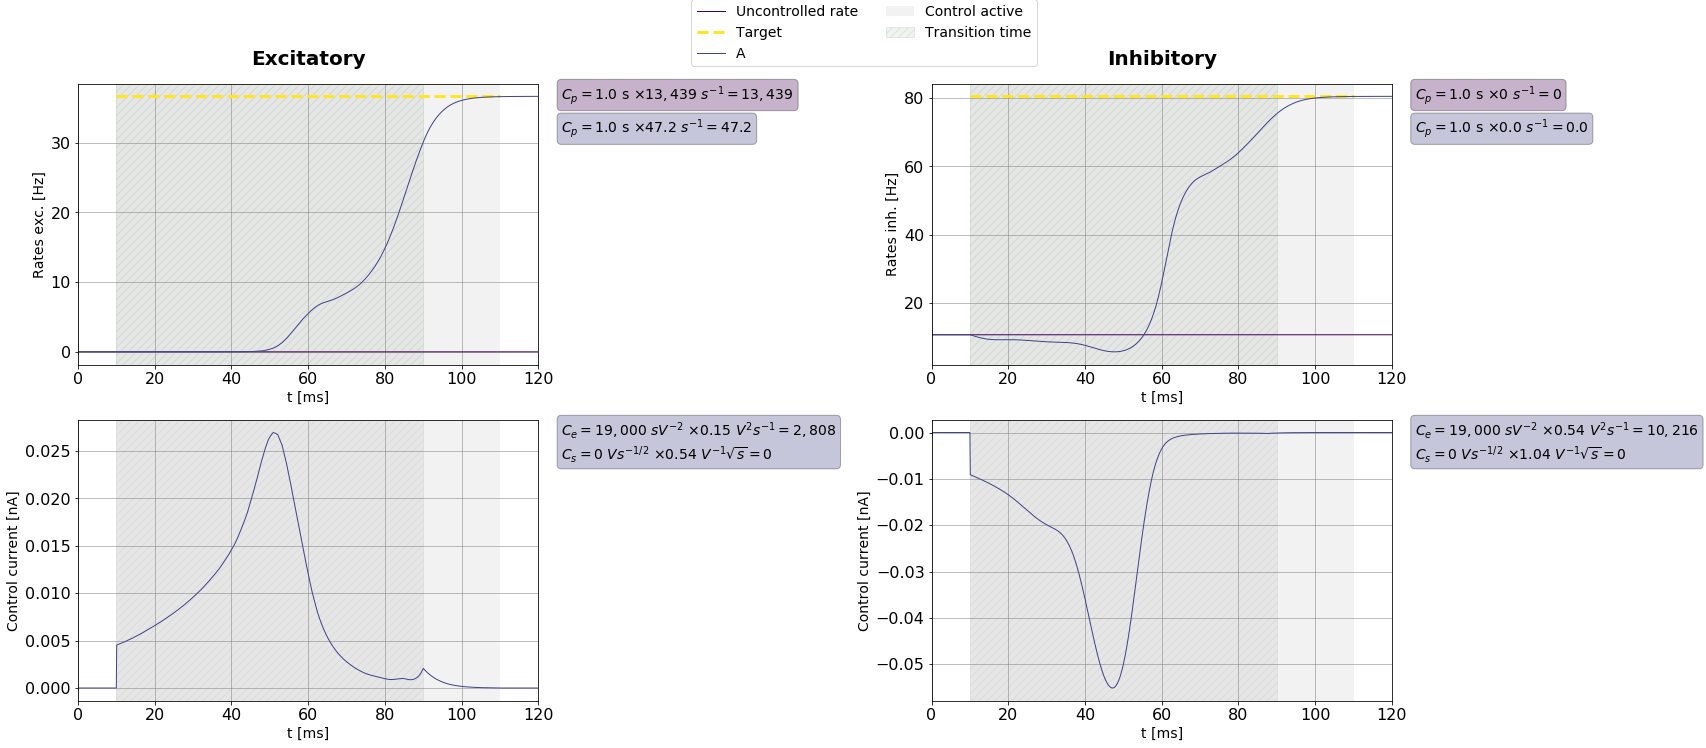

In [20]:
c_ = 2
case = sheet + str(c_) + "c"
cost.setParams(1.0, 1.9 * 1e4, 0.)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlc[c_][:,:,n_pre-1:-n_post+1]
#control3 = bestControlc[c_][:,:,n_pre-1:-n_post+1]

weightsc = [ [], [], [] ]

weightsc[c_] = cost.getParams()

# cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]
cgv = None
max_it = 100

bestControlc[c_], bestStatec[c_], costc[c_], runtimec[c_], gradc[c_], phic[c_], costnodec[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

print( "max, min in exc array = ", np.amax(bestControlc[c_][0,0,:]), np.amin(bestControlc[c_][0,0,:]) )
print( "max, min in inh array = ", np.amax(bestControlc[c_][0,1,:]), np.amin(bestControlc[c_][0,1,:]) )

plotFunc.plot_control_current(aln, [bestControlc[c_]], [costnodec[c_]], [weightsc[c_]], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time, labels_ = ["A"],
                      precision_variables_ = prec_vars)

# 13438

In [183]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.8 * 1e5, 3.8 * 1e4)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
#control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control3 = bestControle[c_][:,:,n_pre-1:-n_post+1] # no input in exc node
control5 = bestControla[c_][:,:,n_pre-1:-n_post+1] # no input in exc node

weightsa = [ [], [], [] ]
weightsa[c_] = cost.getParams()

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 20

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_], costnodea[c_] = aln.A1(
        control5, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

print( "max, min in exc array = ", np.amax(bestControla[c_][0,0,:]), np.amin(bestControla[c_][0,0,:]) )
print( "max, min in inh array = ", np.amax(bestControla[c_][0,1,:]), np.amin(bestControla[c_][0,1,:]) )
    
print("final value exc rate: ", bestStatea[c_][0,0,-1])

set cost params:  1.0 80000.0 38000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22108.220390189916
Gradient descend method:  None
RUN  1 , total integrated cost =  22108.220390189916


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1 , total integrated cost =  22108.220390189916
Improved over  1  iterations in  0.18082579999463633  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.17454881394804 -56.17455046012667
max, min in exc array =  2.252147843261711e-16 -2.890436966899526e-17
max, min in inh array =  0.014325147081678744 -0.1265135467641148
final value exc rate:  47.50971664567229


In [182]:
c_ = 2
case = sheet + str(c_) + "d"
cost.setParams(1.0, 0.9 * 1e5, 3.7 * 1e4)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
#control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlc[c_][:,:,n_pre-1:-n_post+1] # input in exc node
#control4 = bestControld[c_][:,:,n_pre-1:-n_post+1] # input in exc node
control6 = bestControld[c_][:,:,n_pre-1:-n_post+1] # input in exc node

weightsd = [ [], [], [] ]
weightsd[c_] = cost.getParams()

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 3000

bestControld[c_], bestStated[c_], costd[c_], runtimed[c_], gradd[c_], phid[c_], costnoded[c_] = aln.A1(
        control6, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

print( "max, min in exc array = ", np.amax(bestControld[c_][0,0,:]), np.amin(bestControld[c_][0,0,:]) )
print( "max, min in inh array = ", np.amax(bestControld[c_][0,1,:]), np.amin(bestControld[c_][0,1,:]) )
    
print("final value exc rate: ", bestStated[c_][0,0,-1])

set cost params:  1.0 90000.0 37000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22509.338795988682
Gradient descend method:  None
RUN  1 , total integrated cost =  22509.338795988682
Control only changes marginally.
RUN  1 , total integrated cost =  22509.338795988682
Improved over  1  iterations in  0.17345190000196453  seconds by  0.0  percent.


ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.17455322848051 -56.174554702942956
max, min in exc array =  0.004424898616144747 -0.0005451838680931867
max, min in inh array =  0.01423775889030629 -0.12403995955169236
final value exc rate:  47.509722769747995


In [32]:
c_ = 2
case = sheet + str(c_) + "e"
cost.setParams(1.0, 0., 1.0 * 1e4)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
#control2 = bestControle[c_][:,:,n_pre-1:-n_post+1] # 22442


# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 100
weightse[c_] = cost.getParams()

bestControle[c_], bestStatee[c_], coste[c_], runtimee[c_], grade[c_], phie[c_], costnodee[c_] =  aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

print( "max, min in exc array = ", np.amax(bestControle[c_][0,0,:]), np.amin(bestControle[c_][0,0,:]) )
print( "max, min in inh array = ", np.amax(bestControle[c_][0,1,:]), np.amin(bestControle[c_][0,1,:]) )

#plotFunc.plot_control_current(aln, [bestControle[c_]], [costnodee[c_]], [weightse[c_]], dur, dur_pre, dur_post, initVars, target,
#                      path, filename_ = case, transition_time_ = trans_time, labels_ = ["B"],
#                      precision_variables_ = prec_vars)

ERROR:root:Problem in initial value trasfer


set cost params:  1.0 0.0 10000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13313.244591442965
Gradient descend method:  None
RUN  1 , total integrated cost =  13313.244591442965
Control only changes marginally.
RUN  1 , total integrated cost =  13313.244591442965
Improved over  1  iterations in  0.16894200000001547  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.95842366257097 -55.9584510270381
max, min in exc array =  2.315755708016422e-17 0.0
max, min in inh array =  1.4586675657402263e-10 -0.3433832321368587


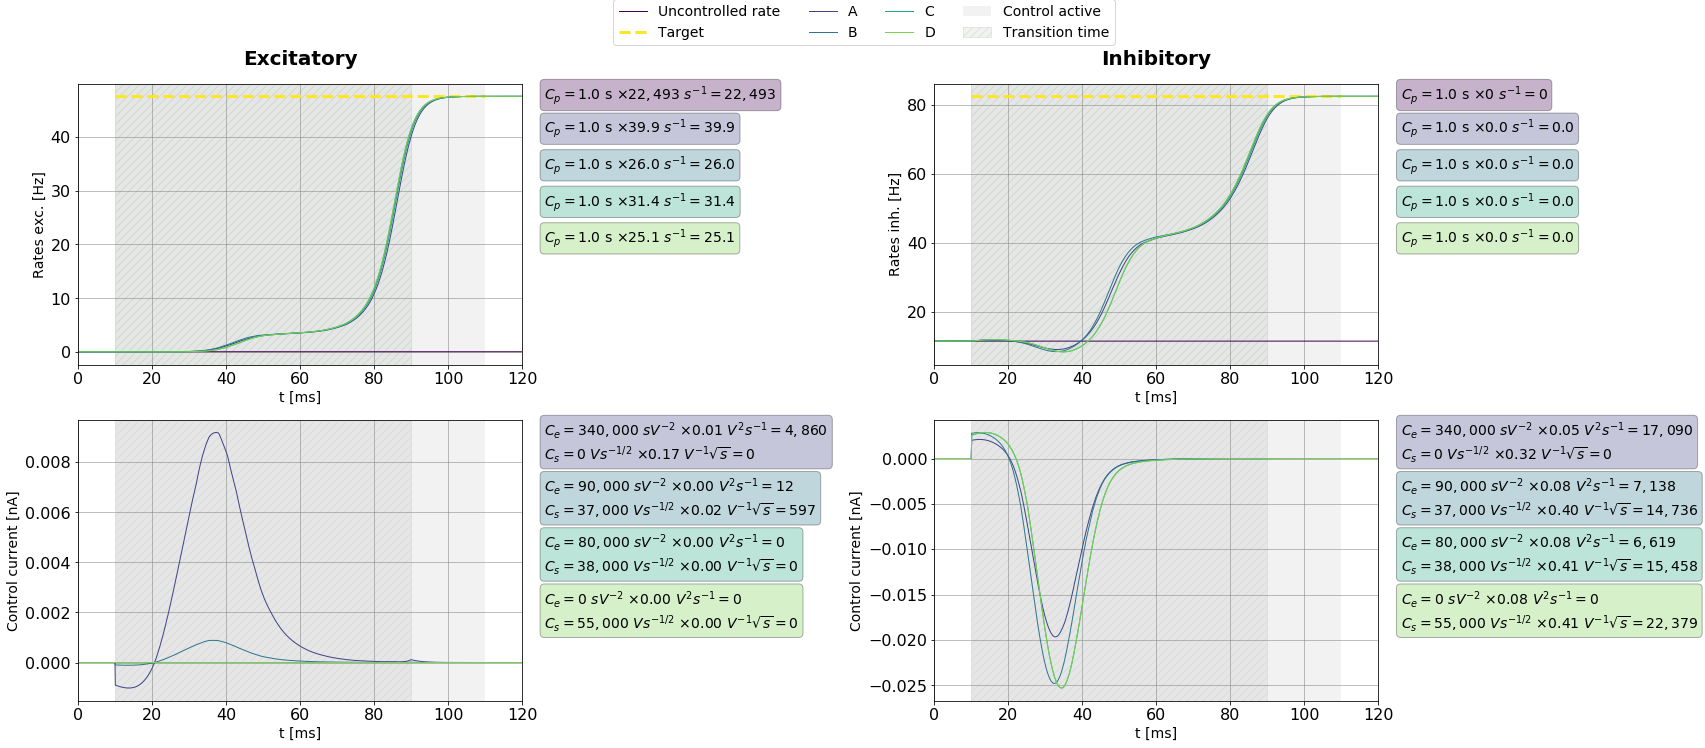

In [203]:
c_ = 2
case = sheet + str(c_) + "_all"
plotFunc.plot_control_current(aln, [bestControlc[c_], bestControld[c_], bestControla[c_], bestControle[c_]],
        [costnodec[c_], costnoded[c_], costnodea[c_], costnodee[c_]],
        [weightsc[c_], weightsd[c_], weightsa[c_], weightse[c_]], dur, dur_pre, dur_post, initVars, target,
        path, filename_ = case, transition_time_ = trans_time, labels_ = ["A", "B", "C", "D"],
        precision_variables_ = prec_vars)

In [33]:
###### HEATMAP for cost depending on weights

N_e = 6
e_max = 2. * 1e4
e_weights = np.linspace(0, e_max, num=N_e, endpoint=False)

N_s = 6
s_max = 1.1 * 1e4
s_weights = np.linspace(0, s_max, num=N_s, endpoint=False)

weights_array = np.zeros(( N_e,N_s,2 ))
for ind_e in range(N_e):
    for ind_s in range(N_s):
        weights_array[ind_e,ind_s,0] = e_weights[ind_e]
        weights_array[ind_e,ind_s,1] = s_weights[ind_s]

c_ = 2
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]
trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

#control5 = bestControla[c_][:,:,n_pre-1:-n_post+1]
#control4 = bestControlc[c_][:,:,n_pre-1:-n_post+1]
#control5 = bestControle[c_][:,:,n_pre-1:-n_post+1]

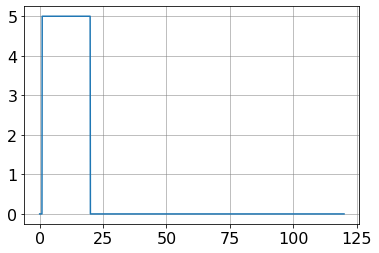

In [34]:
# zero control : 22493.494361608944
start_cntrl = aln.getZeroControl()

control_ = np.zeros((N_e, N_s, start_cntrl.shape[0], start_cntrl.shape[1], start_cntrl.shape[2]))
cost_nodewise_ = np.zeros(( N_e, N_s, 1, 3, 6 ))
cost_total_ = np.zeros(( N_e, N_s ))
#cost_exc_node_node1zero = np.zeros((N_e, N_s))
#cost_2d_2_node1input = np.zeros((N_e, N_s))
#cost_exc_node_node1input = np.zeros((N_e, N_s))


start_cntrl[0,0,:10] = 0.
start_cntrl[0,0,10:200] = 5.
start_cntrl[0,0,200:] = 0.
start_cntrl[0,1,:10] = 0.
start_cntrl[0,1,10:200] = -5.
start_cntrl[0,1,200:] = 0.

for ind_e in range(len(e_weights)):
    for ind_s in range(len(s_weights)):
        control_[ind_e, ind_s] = start_cntrl
            
            
t_ = np.arange(0, control_.shape[4]*aln.params.dt, aln.params.dt)
plt.plot(t_, control_[0,0,0,0,:])

In [109]:
cgv_list = [None]#, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]
cgv = None
max_it = 1000
tol = 1e-20

#13438

first_it = True

for cgv in cgv_list:

    for ind_e in range(len(e_weights)):
        for ind_s in range(len(s_weights)):

            print("-------------", ind_e, ind_s)


            c_e = e_weights[ind_e]
            c_s = s_weights[ind_s]

            control5 = control_[ind_e,ind_s,:,:,n_pre-1:-n_post+1]

            cost.setParams(1.0, c_e, c_s)
            aln.params.duration = dur
            setinit(initVars)

            bc, bs, cost_, rt, gr, ph, cost_node = aln.A1(control5,
                target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
                startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
                t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
                prec_variables_ = prec_vars, transition_time_ = trans_time)

            j = 1
            while cost_[-j] == 0.:
                j += 1
            cost_total_[ind_e,ind_s] = cost_[-j]
            cost_nodewise_[ind_e,ind_s,0,0,0] = cost_node[0][0,0]
            cost_nodewise_[ind_e,ind_s,0,0,1] = cost_node[0][0,1]
            cost_nodewise_[ind_e,ind_s,0,1,0] = cost_node[1][0,0]
            cost_nodewise_[ind_e,ind_s,0,1,1] = cost_node[1][0,1]
            cost_nodewise_[ind_e,ind_s,0,2,0] = cost_node[2][0,0]
            cost_nodewise_[ind_e,ind_s,0,2,1] = cost_node[2][0,1]

            control_[ind_e,ind_s,:,:,:] = bc[:,:,:]

            # 0,1 : 3567

------------- 0 0
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.85872278634977e-19
Gradient descend method:  None
RUN  1 , total integrated cost =  9.793912641206295e-19
RUN  2 , total integrated cost =  9.731807280260752e-19
RUN  3 , total integrated cost =  9.66776730345218e-19
RUN  4 , total integrated cost =  9.606711996343056e-19
RUN  5 , total integrated cost =  9.548415788814973e-19
RUN  6 , total integrated cost =  9.492115790122001e-19
RUN  7 , total integrated cost =  9.435099602334137e-19
RUN  8 , total integrated cost =  9.378834227087077e-19
RUN  9 , total integrated cost =  9.323195873323583e-19
RUN  10 , total integrated cost =  9.267223068284715e-19
RUN  11 , total integrated cost =  9.212750511115119e-19
RUN  12 , total integrated cost =  9.156839579403137e-19
RUN  13 , total integrated cost =  9.099494618674289e-19
RUN  14 , total integrated cost =  9.039603535662666e-19
RUN  15 , total integrated cost =  8.978

ERROR:root:Problem in initial value trasfer


Cost negligibly small.
RUN  749 , total integrated cost =  9.98047860137658e-21
Improved over  749  iterations in  34.16928740000003  seconds by  98.98764994029497  percent.
------------- 0 1
set cost params:  1.0 0.0 1833.3333333333333
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2450.3816975457767
Gradient descend method:  None
RUN  1 , total integrated cost =  2450.3816975457767
Control only changes marginally.
RUN  1 , total integrated cost =  2450.3816975457767
Improved over  1  iterations in  0.1618384999992486  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.959063369235864 -55.95907468477795
------------- 0 2
set cost params:  1.0 0.0 3666.6666666666665
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4892.787242352472
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4892.787242352472
Control only changes marginally.
RUN  1 , total integrated cost =  4892.787242352472
Improved over  1  iterations in  0.1741186999997808  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.958861968953094 -55.95887833422931
------------- 0 3
set cost params:  1.0 0.0 5500.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7332.448157153691
Gradient descend method:  None
RUN  1 , total integrated cost =  7332.448157153691
Control only changes marginally.


...

RUN  7 , total integrated cost =  12061.834696415157
Control only changes marginally.
RUN  7 , total integrated cost =  12061.834696415157
Improved over  7  iterations in  0.7477357999996457  seconds by  4.341117687545193e-09  percent.
Problem in initial value trasfer:  Vmean_exc -55.958520087658655 -55.958543645320304
------------- 4 2
set cost params:  1.0 13333.333333333334 3666.6666666666665
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14895.239604355445
Gradient descend method:  None
RUN  1 , total integrated cost =  14895.239604355445


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1 , total integrated cost =  14895.239604355445
Improved over  1  iterations in  0.18165890000000218  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.95838573342139 -55.95841280995436
------------- 4 3
set cost params:  1.0 13333.333333333334 5500.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13438.778697917565
Gradient descend method:  None
RUN  1 , total integrated cost =  13438.778697917565
Control only changes marginally.
RUN  1 , total integrated cost =  13438.778697917565
Improved over  1  iterations in  0.19355349999932514  seconds by  0.0  percent.
------------- 4 4
set cost params:  1.0 13333.333333333334 7333.333333333333
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13438.778697917565
Gradient descend method:  None
RUN  1 , total integrated cost =  13438.778697917565
Control only changes marginally.
RUN  1 , total integrated cost =  13438.778697917565
Improv

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1 , total integrated cost =  11471.152560813875
Improved over  1  iterations in  0.18312969999988127  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -55.95849398034857 -55.95851811230941
------------- 5 1
set cost params:  1.0 16666.666666666668 1833.3333333333333
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13438.778697917565
Gradient descend method:  None
RUN  1 , total integrated cost =  13438.778697917565
Control only changes marginally.
RUN  1 , total integrated cost =  13438.778697917565
Improved over  1  iterations in  0.20139360000030138  seconds by  0.0  percent.
------------- 5 2
set cost params:  1.0 16666.666666666668 3666.6666666666665
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13438.778697917565
Gradient descend method:  None
RUN  1 , total integrated cost =  13438.778697917565
Control only changes marginally.
RUN  1 , total integrated cost =  13438.778697

In [110]:
# safe results 
with open('sc2_3_0_control.pickle','wb') as f:
    pickle.dump(control_, f)
    
with open('sc2_3_0_control.pickle','rb') as f:
    arrayname1 = pickle.load(f)

print(arrayname1.shape)

with open('sc2_3_0_cost_nodewise.pickle','wb') as f:
    pickle.dump(cost_nodewise_, f)
    
with open('sc2_3_0_cost_nodewise.pickle','rb') as f:
    arrayname1 = pickle.load(f)

print(arrayname1.shape)

with open('sc2_3_0_cost_total.pickle','wb') as f:
    pickle.dump(cost_total_, f)
    
with open('sc2_3_0_cost_total.pickle','rb') as f:
    arrayname1 = pickle.load(f)

print(arrayname1.shape)

print(cost_total_)

(6, 6, 1, 6, 1201)
(6, 6, 1, 3, 6)
(6, 6)
[[9.9805e-21 2.4504e+03 4.8928e+03 7.3324e+03 9.7701e+03 1.2206e+04]
 [2.3077e+03 5.1282e+03 7.7801e+03 1.0276e+04 1.2712e+04 1.5146e+04]
 [4.6042e+03 7.4636e+03 1.0236e+04 1.2924e+04 1.5531e+04 1.3439e+04]
 [6.8957e+03 9.7674e+03 1.2581e+04 1.5338e+04 1.3439e+04 1.3439e+04]
 [9.1844e+03 1.2062e+04 1.4895e+04 1.3439e+04 1.3439e+04 1.3439e+04]
 [1.1471e+04 1.3439e+04 1.3439e+04 1.3439e+04 1.3439e+04 1.3439e+04]]


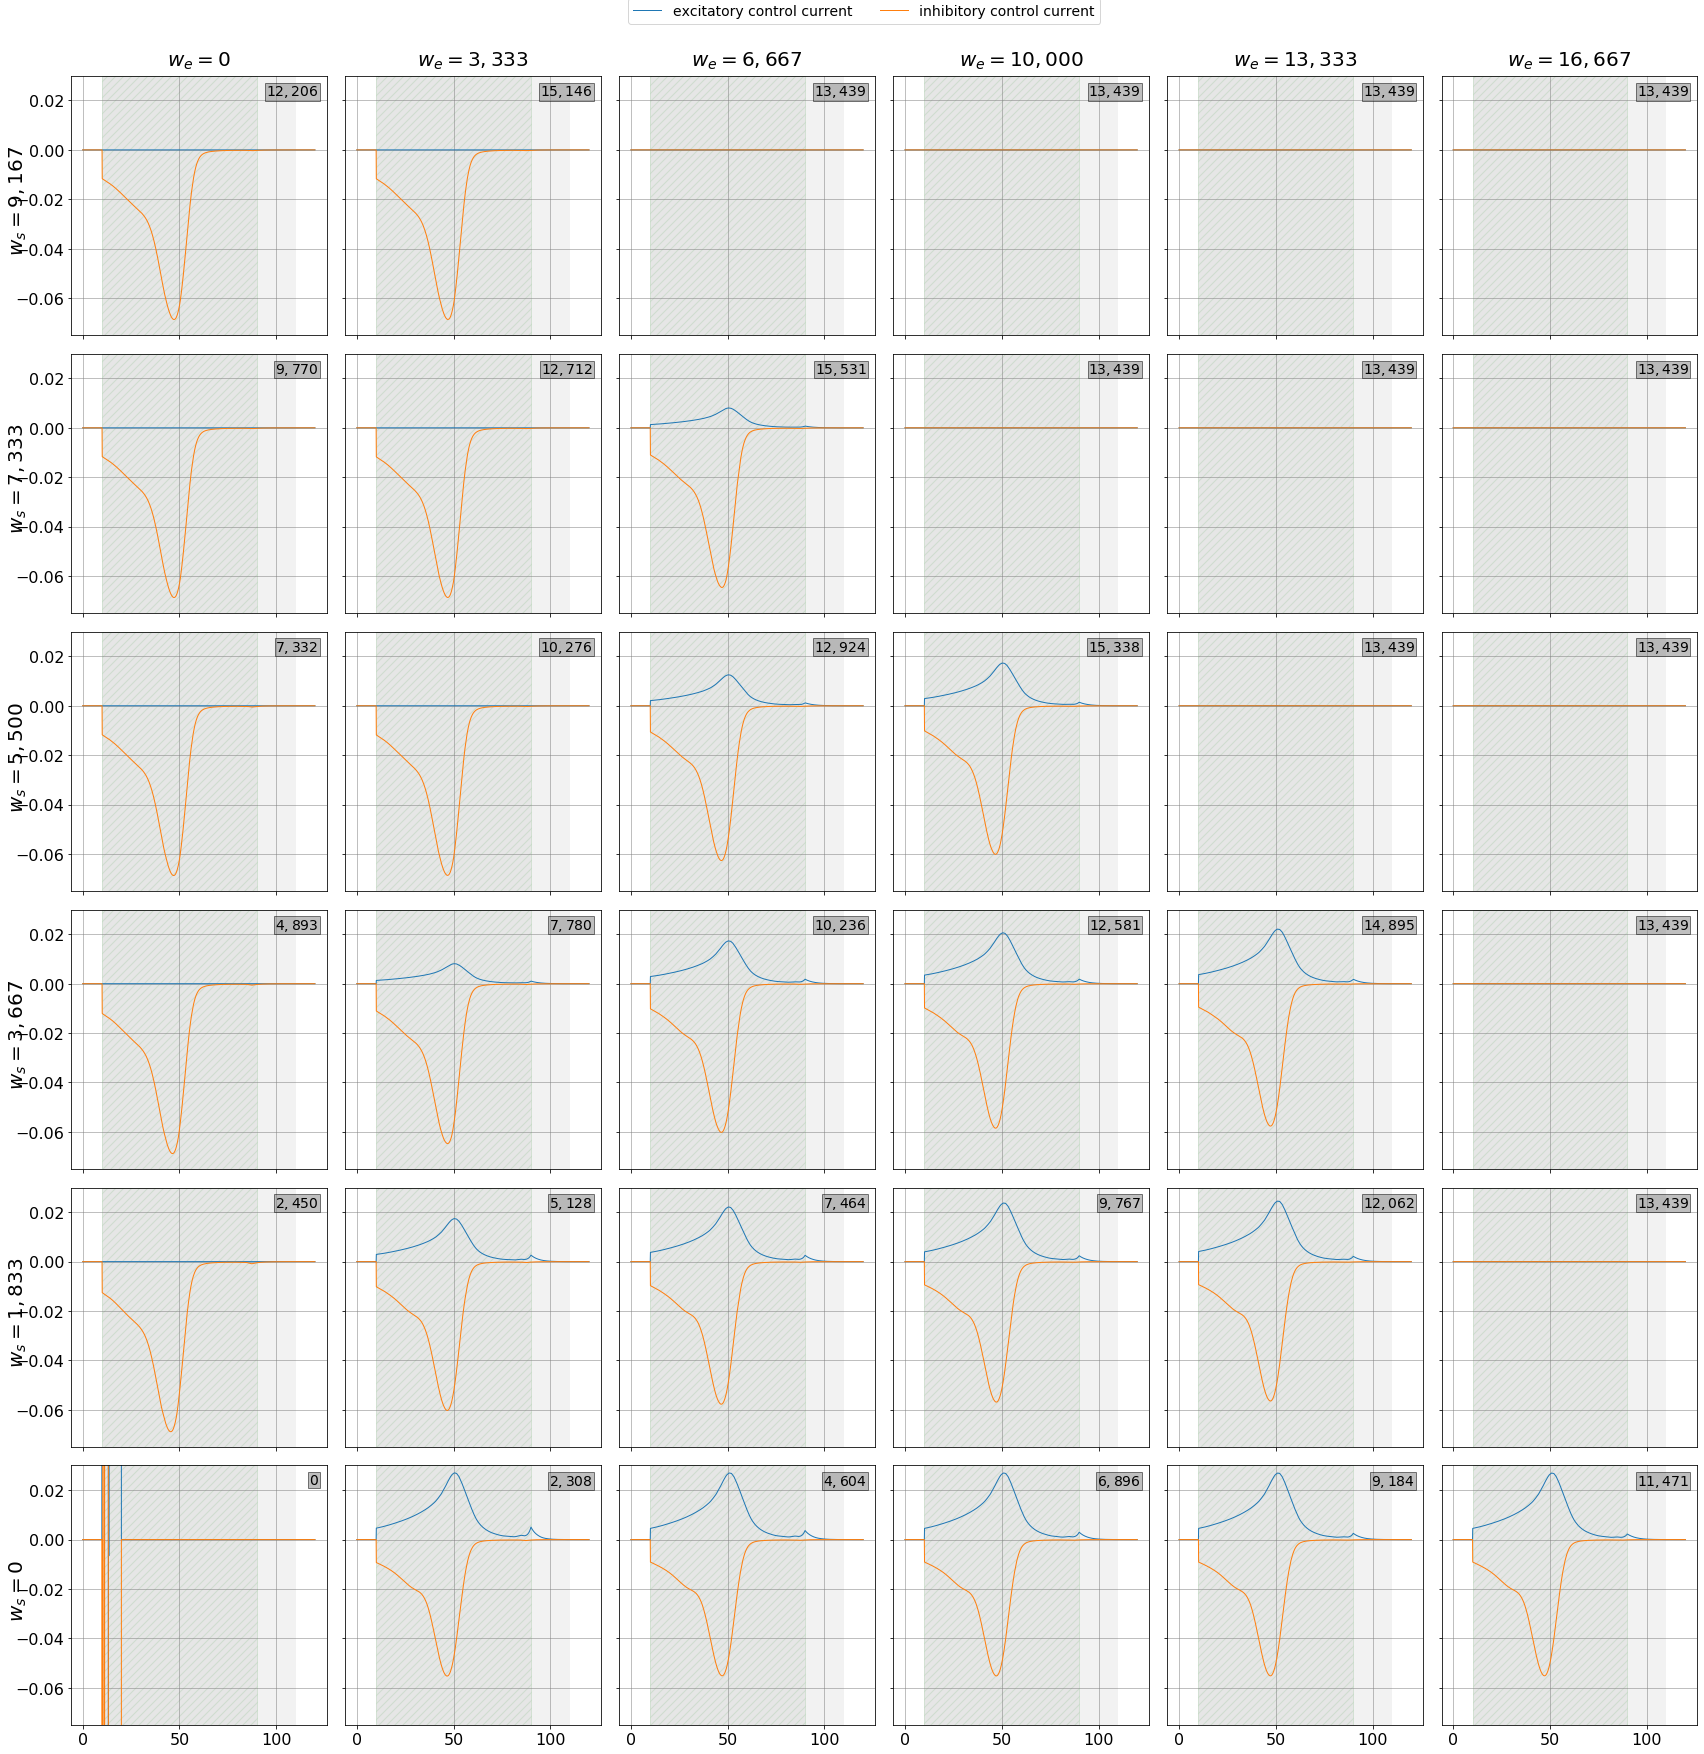

In [111]:
ylim = [-0.075, 0.03]

plotFunc.plot_control_array(aln, control_, cost_total_, weights_array, dur, dur_pre,
            dur_post, initVars, target, ylim, path, filename_ = 'control_array_plot_sc2_3_0',
            transition_time_ = trans_time, precision_variables_=prec_vars)

In [55]:
# load results


with open('sc2_2_0_control.pickle','rb') as f:
    control_ = pickle.load(f)
print(control_.shape)
    
with open('sc2_2_0_cost_nodewise.pickle','rb') as f:
    cost_nodewise_ = pickle.load(f)
print(cost_nodewise_.shape)
    
with open('sc2_2_0_cost_total.pickle','rb') as f:
    cost_total_ = pickle.load(f)
print(cost_total_.shape)


(6, 6, 1, 6, 1201)
(6, 6, 1, 3, 6)
(6, 6)


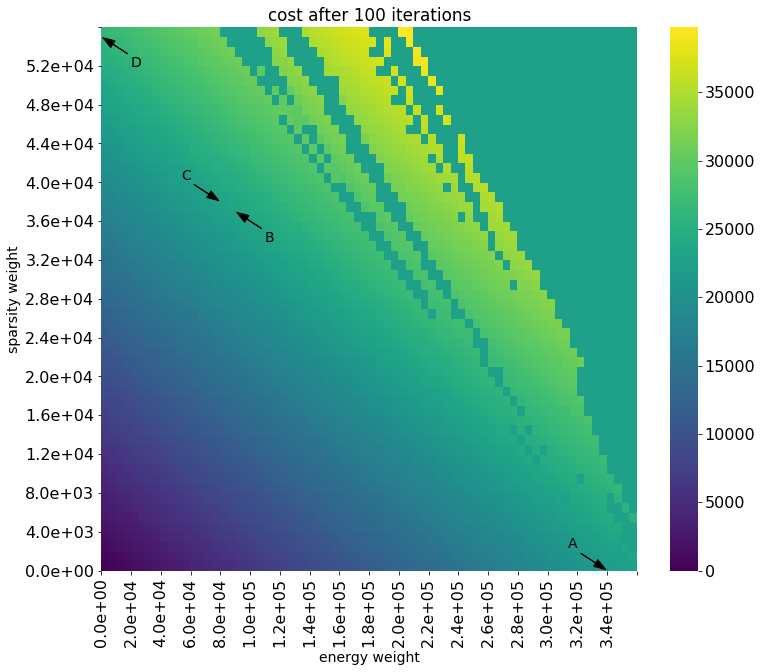

In [210]:
test_cost = cost_2d_2_node1input
too_high_cost = []
local_min = []

c_ = 2

xd, yd = 0, weightse[c_][2]
yd_arrow = N_s * yd/s_max

xa, ya = weightsc[c_][1], 0
xa_arrow = N_e * xa/e_max

xc, yc = weightsa[c_][1], weightsa[c_][2]
xc_arrow = N_e * xc/e_max
yc_arrow = N_s * yc/s_max

xb, yb = weightsd[c_][1], weightsd[c_][2]
xb_arrow = N_e * xb/e_max
yb_arrow = N_s * yb/s_max

0.8 * 1e5, 3.8 * 1e4

arrow_xlength = 4
arrow_ylength = 2

max_it = 100

for c1_ in range(N_e):
    for c2_ in range(N_s):
        if test_cost[c1_,c2_] > 22492 and test_cost[c1_,c2_] < 22495:
            #print("presumably local minimum for ", c1_, c2_)
            local_min.append([c1_,c2_])
        if test_cost[c1_,c2_] > 22500:
            #print("too high cost for ", c1_, c2_)
            too_high_cost.append([c1_,c2_])
            #test_cost[c1_,c2_] = 22500
        if test_cost[c1_,c2_] == 0.:
            print("zero cost for ", c1_, c2_)
            #test_cost[c1_,c2_] = 22500

n_xticks = 19
e_ticklabels = ["{:.1e}".format(x) for x in e_weights[::int(N_e / (n_xticks-1))  ]]
n_yticks = 15
s_ticklabels = ["{:.1e}".format(x) for x in s_weights[::int(N_s / (n_yticks-1))  ]]

fig, ax = plt.subplots(figsize=(12,10)) 
ax = sns.heatmap(test_cost.T, cmap="viridis")
ax.set(xlabel='energy weight', ylabel='sparsity weight', title='cost after {} iterations'.format(max_it))
ax.invert_yaxis()

ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(e_ticklabels, rotation=90)

ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(s_ticklabels, rotation=0)

ax.annotate('A', xy=(xa_arrow, 0), xytext=(xa_arrow-arrow_xlength, arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('D', xy=(0, yd_arrow), xytext=(arrow_xlength, yd_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('C', xy=(xc_arrow, yc_arrow), xytext=(xc_arrow-arrow_xlength, yc_arrow+arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('B', xy=(xb_arrow, yb_arrow), xytext=(xb_arrow+arrow_xlength, yb_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))

plt.savefig(os.path.join(path, 'heatmap_cost_' + str(c_) ) )
plt.show()

In [212]:
cgv = None
max_it = 100
control3 = bc[:,:,n_pre-1:-n_post+1]
aln.params.duration = dur

cost_2d_2_node1input_maxcost = cost_2d_2_node1input.copy()

# too_high_cost, local_min

for indices in too_high_cost:
    
    ind_e = indices[0]
    ind_s = indices[1]
        
    print("-------------", ind_e, ind_s)

    c_e = e_weights[ind_e]
    c_s = s_weights[ind_s]

    cost.setParams(1.0, c_e, c_s)
    aln.params.duration = dur
    setinit(initVars)
    
    start_cntrl = control0

    bc, bs, cost_, rt, gr, ph, cn_ = aln.A1(
        start_cntrl, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

    j = 1
    while cost_[-j] == 0.:
        j += 1
    cost_2d_2_node1input_maxcost[ind_e,ind_s] = cost_[-j]

------------- 0 48
set cost params:  1.0 0.0 48000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.168333800000255  seconds by  0.0  percent.
------------- 0 49
set cost params:  1.0 0.0 49000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16961469998932444  seconds by  0.0  percent.
------------- 0 50
set cost params:  1.0 0.0 50000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1743690000002971  seconds by  0.0  percent.
------------- 2 51
set cost params:  1.0 10000.0 51000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1839314000098966  seconds by  0.0  percent.
------------- 2 52
set cost params:  1.0 10000.0 52000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17592200000945013  seconds by  0

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1758321000088472  seconds by  0.0  percent.
------------- 4 50
set cost params:  1.0 20000.0 50000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17886230000294745  seconds by  0.0  percent.
------------- 4 51
set cost params:  1.0 20000.0 51000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17701929999748245  seconds by  

Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.19217619999835733  seconds by  0.0  percent.
------------- 6 46
set cost params:  1.0 30000.0 46000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.2017288000060944  seconds by  0.0  percent.
------------- 6 47
set cost params:  1.0 30000.0 47000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.21208159999514464  seconds by  0.0  percent.
------------- 6 48
set cost params:  1.

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.21861369999533053  seconds by  0.0  percent.
------------- 7 54
set cost params:  1.0 35000.0 54000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.2348958000075072  seconds by  0.0  percent.
------------- 7 55
set cost params:  1.0 35000.0 55000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.219685500007472  seconds by  0.

...

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.21727419999660924  seconds by  0.0  percent.
------------- 63 22
set cost params:  1.0 315000.0 22000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.19829020000179298  seconds by  0.0  percent.
------------- 64 4
set cost params:  1.0 320000.0 4000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1844312000030186  seconds by

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17665429999760818  seconds by  0.0  percent.
------------- 65 10
set cost params:  1.0 325000.0 10000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17685770000389311  seconds by  0.0  percent.
------------- 65 11
set cost params:  1.0 325000.0 11000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1762806000042474  seconds 

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17703580000670627  seconds by  0.0  percent.
------------- 67 7
set cost params:  1.0 335000.0 7000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1726226000027964  seconds by  0.0  percent.
------------- 67 8
set cost params:  1.0 335000.0 8000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17337599999154918  seconds by  

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  22492.994012105573
RUN  4 , total integrated cost =  22492.994012105573
Control only changes marginally.
RUN  4 , total integrated cost =  22492.994012105573
Improved over  4  iterations in  0.30927349999547005  seconds by  0.0022244187378106517  percent.
Problem in initial value trasfer:  Vmean_exc -56.29219302541232 -56.29223988069473
------------- 70 2
set cost params:  1.0 350000.0 2000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17734130000462756  seconds by  0.0  percent.
------------- 70 6
set cost params:  1.0 350000.0 6000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.4943616089

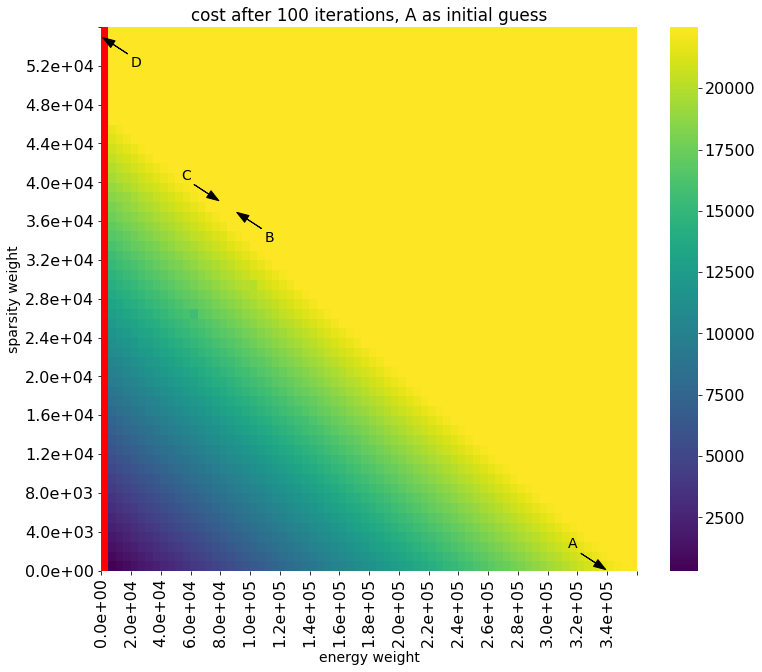

In [213]:
test_cost = cost_2d_2_node1input_maxcost

jumps_input_to_zero = test_cost.copy()
for i_e in range(len(e_weights)):
    for i_s in range(len(s_weights)):
        jumps_input_to_zero[i_e, i_s] = 0
        if np.abs(cost_exc_node_node1input[i_e, i_s]) < 1e-6:
            if np.abs(cost_2d_2_node1input[i_e,i_s] - 22493.49) > 0.5:
                jumps_input_to_zero[i_e, i_s] = 1
            
#print("jumps to zero in exc current control ", jumps_input_to_zero)        
        
fig, ax = plt.subplots(figsize=(12,10)) 
ax = sns.heatmap(test_cost.T, mask=jumps_input_to_zero.T == 1, cmap="viridis")
ax.set_facecolor('red')
ax.set(xlabel='energy weight', ylabel='sparsity weight', title='cost after {} iterations, A as initial guess'.format(max_it))
ax.invert_yaxis()

ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(e_ticklabels, rotation=90)

ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(s_ticklabels, rotation=0)

ax.annotate('A', xy=(xa_arrow, 0), xytext=(xa_arrow-arrow_xlength, arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('D', xy=(0, yd_arrow), xytext=(arrow_xlength, yd_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('C', xy=(xc_arrow, yc_arrow), xytext=(xc_arrow-arrow_xlength, yc_arrow+arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('B', xy=(xb_arrow, yb_arrow), xytext=(xb_arrow+arrow_xlength, yb_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))

plt.savefig(os.path.join(path, 'heatmap_cost_node1input' + str(c_) ) )
plt.show()

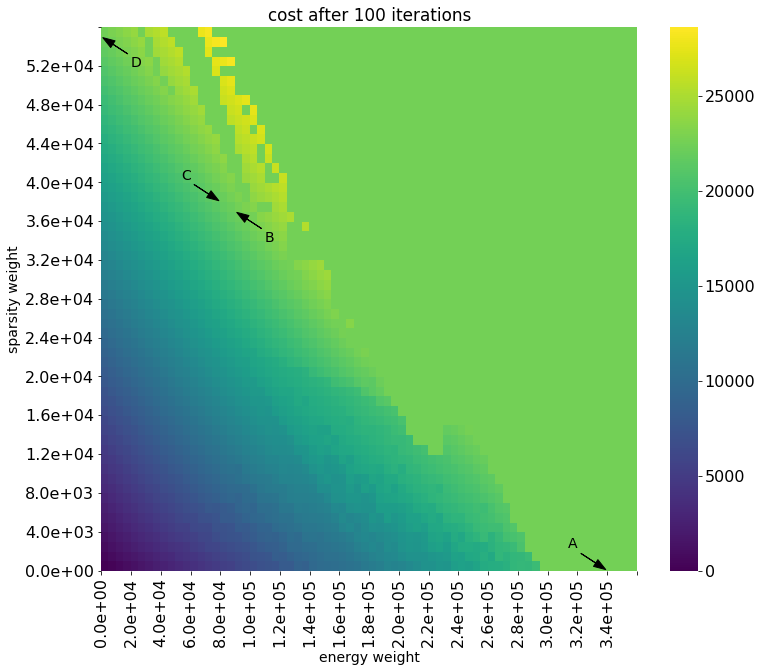

In [214]:
test_cost = cost_2d_2_node1zero
too_high_cost = []
local_min = []

for c1_ in range(N_e):
    for c2_ in range(N_s):
        if test_cost[c1_,c2_] > 22492 and test_cost[c1_,c2_] < 22495:
            #print("presumably local minimum for ", c1_, c2_)
            local_min.append([c1_,c2_])
        if test_cost[c1_,c2_] > 22500:
            #print("too high cost for ", c1_, c2_)
            too_high_cost.append([c1_,c2_])
            #test_cost[c1_,c2_] = 22500
        if test_cost[c1_,c2_] == 0.:
            print("zero cost for ", c1_, c2_)
            #test_cost[c1_,c2_] = 22500

fig, ax = plt.subplots(figsize=(12,10)) 
ax = sns.heatmap(test_cost.T, cmap="viridis")
ax.set(xlabel='energy weight', ylabel='sparsity weight', title='cost after {} iterations'.format(max_it))
ax.invert_yaxis()

ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(e_ticklabels, rotation=90)

ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(s_ticklabels, rotation=0)

ax.annotate('A', xy=(xa_arrow, 0), xytext=(xa_arrow-arrow_xlength, arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('D', xy=(0, yd_arrow), xytext=(arrow_xlength, yd_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('C', xy=(xc_arrow, yc_arrow), xytext=(xc_arrow-arrow_xlength, yc_arrow+arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('B', xy=(xb_arrow, yb_arrow), xytext=(xb_arrow+arrow_xlength, yb_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))

plt.savefig(os.path.join(path, 'heatmap_cost_' + str(c_) ) )
plt.show()

In [108]:
cgv = None
max_it = 100
control3 = bc[:,:,n_pre-1:-n_post+1]
aln.params.duration = dur

cost_2d_2_node1zero_maxcost = cost_2d_2_node1zero.copy()

# too_high_cost, local_min

for indices in too_high_cost:
    
    ind_e = indices[0]
    ind_s = indices[1]
        
    print("-------------", ind_e, ind_s)

    c_e = e_weights[ind_e]
    c_s = s_weights[ind_s]

    cost.setParams(1.0, c_e, c_s)
    aln.params.duration = dur
    setinit(initVars)
    
    start_cntrl = control0

    bc, bs, cost_, rt, gr, ph, cn_ = aln.A1(
        start_cntrl, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

    j = 1
    while cost_[-j] == 0.:
        j += 1
    cost_2d_2_node1zero_maxcost[ind_e,ind_s] = cost_[-j]

------------- 1 55
set cost params:  1.0 5000.0 55000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1884429000056116  seconds by  0.0  percent.
------------- 2 54
set cost params:  1.0 10000.0 54000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1816465000010794  seconds by  0.0  percent.
------------- 2 55
set cost params:  1.0 10000.0 55000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated co

RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1739570000063395  seconds by  0.0  percent.
------------- 7 54
set cost params:  1.0 35000.0 54000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17564649999258108  seconds by  0.0  percent.
------------- 7 55
set cost params:  1.0 35000.0 55000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17140830001153518  seconds by  0.0  percent.
------------- 8 48
set cost params:  1.0 40000.0 48000.0
interpolate adj

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.18667129999084864  seconds by  0.0  percent.
------------- 10 51
set cost params:  1.0 50000.0 51000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.19263249999494292  seconds by  0.0  percent.
------------- 10 52
set cost params:  1.0 50000.0 52000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1899227000103565  seconds by

Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17731020000064746  seconds by  0.0  percent.
------------- 13 55
set cost params:  1.0 65000.0 55000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1755399999965448  seconds by  0.0  percent.
------------- 14 41
set cost params:  1.0 70000.0 41000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1769225999887567  seconds by  0.0  percent.
------------- 14 42
set cost params:  

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17516100000648294  seconds by  0.0  percent.
------------- 16 49
set cost params:  1.0 80000.0 49000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.1640969000000041  seconds by  0.0  percent.
------------- 16 50
set cost params:  1.0 80000.0 50000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16848449999815784  seconds by

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.18641219999699388  seconds by  0.0  percent.
------------- 19 36
set cost params:  1.0 95000.0 36000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.18798820000665728  seconds by  0.0  percent.
------------- 19 37
set cost params:  1.0 95000.0 37000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17748630000278354  seconds b

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17391830000269692  seconds by  0.0  percent.
------------- 21 34
set cost params:  1.0 105000.0 34000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16384609999659006  seconds by  0.0  percent.
------------- 21 35
set cost params:  1.0 105000.0 35000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16778380000323523  seconds

RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16982029999780934  seconds by  0.0  percent.
------------- 23 38
set cost params:  1.0 115000.0 38000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16430720000062138  seconds by  0.0  percent.
------------- 23 39
set cost params:  1.0 115000.0 39000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.17031859999406151  seconds

RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.175520000004326  seconds by  0.0  percent.
------------- 28 31
set cost params:  1.0 140000.0 31000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =  22493.494361608944
Improved over  1  iterations in  0.16800900000089314  seconds by  0.0  percent.
------------- 29 27
set cost params:  1.0 145000.0 27000.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
Control only changes marginally.
RUN  1 , total integrated cost =

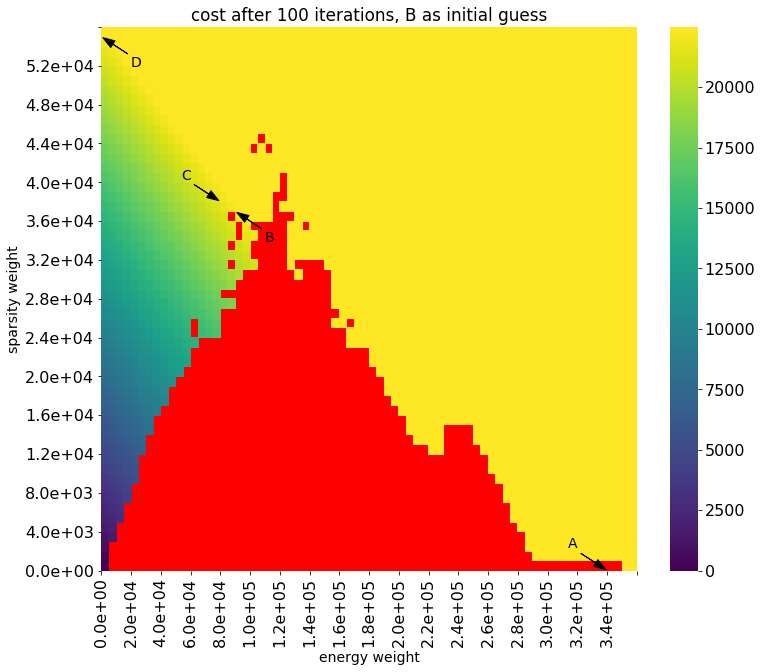

In [215]:
test_cost = cost_2d_2_node1zero_maxcost

jumps_zero_to_input = test_cost.copy()
for i_e in range(len(e_weights)):
    for i_s in range(len(s_weights)):
        jumps_zero_to_input[i_e, i_s] = 0
        if np.abs(cost_exc_node_node1zero[i_e, i_s]) > 1e-6:
            if np.abs(cost_2d_2_node1zero[i_e,i_s] - 22493.49) > 0.5:
                jumps_zero_to_input[i_e, i_s] = 1
            
#print("jumps to input in exc current control ", jumps_zero_to_input)

fig, ax = plt.subplots(figsize=(12,10)) 
ax = sns.heatmap(test_cost.T, mask=jumps_zero_to_input.T == 1, cmap="viridis")
ax.set_facecolor('red')
ax.set(xlabel='energy weight', ylabel='sparsity weight', title='cost after {} iterations, B as initial guess'.format(max_it))
ax.invert_yaxis()

ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(e_ticklabels, rotation=90)

ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(s_ticklabels, rotation=0)

ax.annotate('A', xy=(xa_arrow, 0), xytext=(xa_arrow-arrow_xlength, arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('D', xy=(0, yd_arrow), xytext=(arrow_xlength, yd_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('C', xy=(xc_arrow, yc_arrow), xytext=(xc_arrow-arrow_xlength, yc_arrow+arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('B', xy=(xb_arrow, yb_arrow), xytext=(xb_arrow+arrow_xlength, yb_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))

plt.savefig(os.path.join(path, 'heatmap_cost_node1zero' + str(c_) ) )
plt.show()

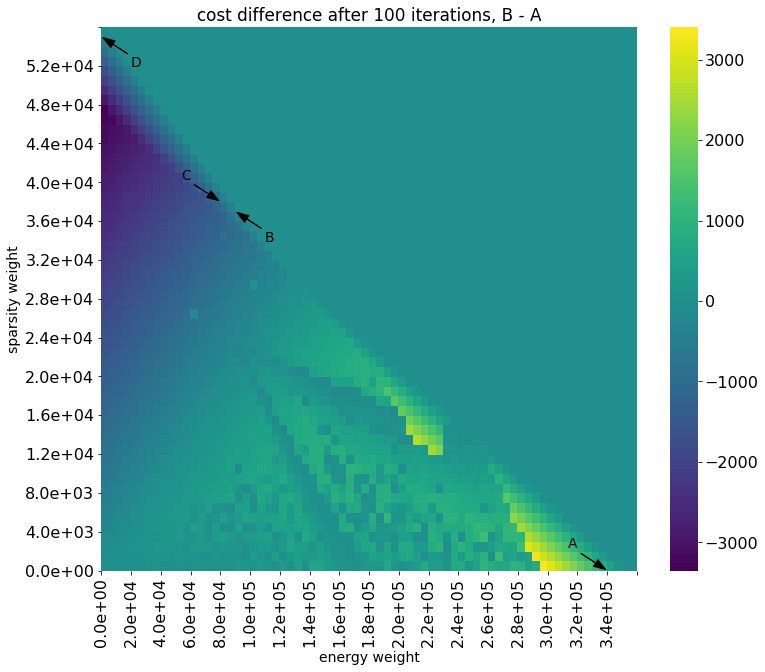

In [216]:
test_cost = cost_2d_2_node1zero_maxcost - cost_2d_2_node1input_maxcost

fig, ax = plt.subplots(figsize=(12,10)) 
ax = sns.heatmap(test_cost.T, cmap="viridis")
ax.set_facecolor('red')
ax.set(xlabel='energy weight', ylabel='sparsity weight',
       title='cost difference after {} iterations, B - A'.format(max_it))
ax.invert_yaxis()

ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(e_ticklabels, rotation=90)

ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(s_ticklabels, rotation=0)

ax.annotate('A', xy=(xa_arrow, 0), xytext=(xa_arrow-arrow_xlength, arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('D', xy=(0, yd_arrow), xytext=(arrow_xlength, yd_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('C', xy=(xc_arrow, yc_arrow), xytext=(xc_arrow-arrow_xlength, yc_arrow+arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('B', xy=(xb_arrow, yb_arrow), xytext=(xb_arrow+arrow_xlength, yb_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))

plt.savefig(os.path.join(path, 'heatmap_cost_diff' + str(c_) ) )
plt.show()

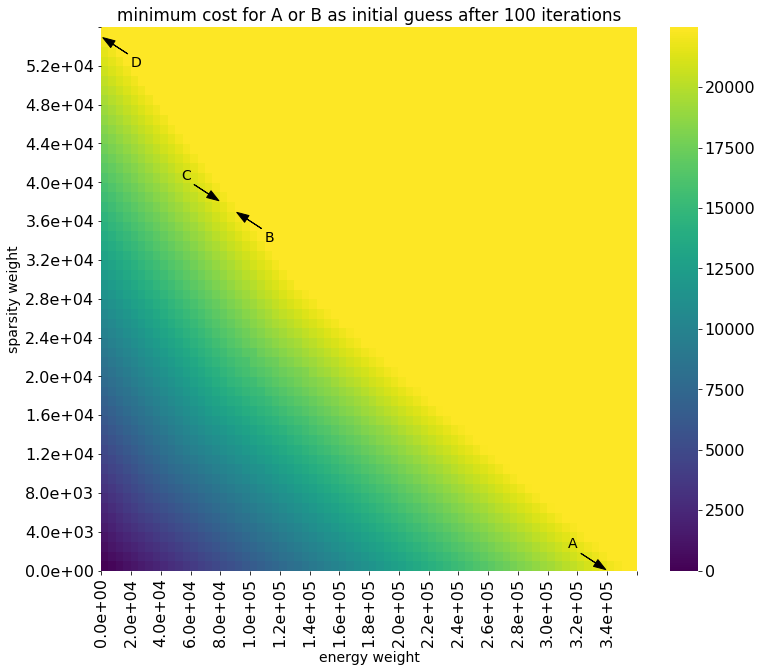

In [217]:
test_cost = cost_2d_2_node1zero_maxcost.copy()
for i_e in range(test_cost.shape[0]):
    for i_s in range(test_cost.shape[1]):
        if cost_2d_2_node1input_maxcost[i_e, i_s] < test_cost[i_e, i_s]:
            test_cost[i_e, i_s] = cost_2d_2_node1input_maxcost[i_e, i_s]

fig, ax = plt.subplots(figsize=(12,10)) 
ax = sns.heatmap(test_cost.T, cmap="viridis")
ax.set_facecolor('red')
ax.set(xlabel='energy weight', ylabel='sparsity weight',
       title='minimum cost for A or B as initial guess after {} iterations'.format(max_it))
ax.invert_yaxis()

ax.xaxis.set_major_locator(ticker.LinearLocator(n_xticks))
ax.set_xticklabels(e_ticklabels, rotation=90)

ax.yaxis.set_major_locator(ticker.LinearLocator(n_yticks))
ax.set_yticklabels(s_ticklabels, rotation=0)

ax.annotate('A', xy=(xa_arrow, 0), xytext=(xa_arrow-arrow_xlength, arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('D', xy=(0, yd_arrow), xytext=(arrow_xlength, yd_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('C', xy=(xc_arrow, yc_arrow), xytext=(xc_arrow-arrow_xlength, yc_arrow+arrow_ylength),
            horizontalalignment='right', verticalalignment='bottom',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))
ax.annotate('B', xy=(xb_arrow, yb_arrow), xytext=(xb_arrow+arrow_xlength, yb_arrow-arrow_ylength),
            horizontalalignment='left', verticalalignment='top',
            arrowprops=dict(facecolor='black', width=0.1, headwidth=8., shrink=0.05))

plt.savefig(os.path.join(path, 'heatmap_cost_' + str(c_) ) )
plt.show()